# 05 – Fusion Layer & Mismatch Detection
**Project:** MoodSyncAI — Multi-Modal Sentiment & Emotion Analyser  
**Module:** Data Analytics-3

### Architecture Overview
```
┌─────────────────────────────────────────────────────────────────────┐
│  INPUT                                                              │
│  ┌──────────────┐          ┌──────────────────────────────────────┐ │
│  │  Face Image  │──────►  │  ResNet50V2 (Face-emotion-detection) │ │
│  └──────────────┘          │  7 classes: Angry/Disgust/Fear/      │ │
│                             │  Happy/Neutral/Sad/Surprise         │ │
│                             └──────────────┬─────────────────────┘ │
│                                            │                        │
│                             ┌──────────────▼─────────────────────┐ │
│                             │   Polarity Bridge (fusion)         │ │
│                             │   Happy/Surprise  → positive        │ │
│                             │   Neutral         → neutral         │ │
│                             │   Angry/Disgust/  → negative        │ │
│                             │   Fear/Sad        →                 │ │
│                             └──────────────┬─────────────────────┘ │
│                                            │                        │
│  ┌──────────────┐          ┌──────────────▼─────────────────────┐ │
│  │  Text Input  │──────►  │  RoBERTa Sentiment (text model)     │ │
│  └──────────────┘          │  3 classes: negative/neutral/       │ │
│                             │  positive                           │ │
│                             └──────────────┬─────────────────────┘ │
│                                            │                        │
│                             ┌──────────────▼─────────────────────┐ │
│                             │    Mismatch Detector               │ │
│                             │    MATCH / SOFT_MISMATCH /         │ │
│                             │    HARD_MISMATCH                   │ │
│                             └────────────────────────────────────┘ │
└─────────────────────────────────────────────────────────────────────┘
```

### Objectives
1. Load both saved models (ResNet50V2 + RoBERTa)
2. Implement the polarity bridge (7-class → 3-class mapping)
3. Implement the mismatch detector with confidence thresholding
4. Run end-to-end fusion on combined image + text inputs
5. Visualise predictions from both modalities side by side
6. Test the assignment brief scenario (Sad face + positive text)
7. Analyse mismatch rate and confidence distributions
8. Benchmark end-to-end latency

---

## 0 – Environment Setup & Imports

In [4]:
import os, sys, time, warnings, json
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
)
import tensorflow as tf

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Correct model path from Face-emotion-detection.ipynb ─────────────
VISUAL_MODEL_PATH = "ResNet50V2_Model.h5"   # update if your filename differs
TEXT_MODEL_PATH   = "saved_models/roberta_sentiment"
CASCADE_PATH      = "haarcascade_frontalface_default.xml"

EMOTION_CLASSES = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
IMG_SHAPE       = 224

# ── Dark matplotlib theme ─────────────────────────────────────────────
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.facecolor": "#111111", "axes.facecolor": "#1c1c1c",
    "axes.edgecolor": "#333333",   "axes.labelcolor": "#cccccc",
    "xtick.color": "#aaaaaa",      "ytick.color": "#aaaaaa",
    "text.color": "#e0e0e0",       "grid.color": "#2a2a2a",
    "grid.linestyle": "--",        "font.family": "DejaVu Sans",
})

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"TF      : {tf.__version__}")
print(f"Device  : {DEVICE}")


Python  : 3.11.13
PyTorch : 2.9.1+cu128
TF      : 2.20.0
Device  : cuda


## 1 – Load Visual Model (ResNet50V2)

Loading the best checkpoint saved during training in `Face-emotion-detection.ipynb`.
The model was trained on FER2013 (28,709 train / 7,178 test) and achieved **66.88% test accuracy**.

In [5]:
# ── Step 1: Verify the file exists and check its size ────────────────
import os
if not os.path.exists(VISUAL_MODEL_PATH):
    raise FileNotFoundError(
        f"Model file not found: {VISUAL_MODEL_PATH}\n"
        "Make sure the file is in the same directory as this notebook."
    )

file_size_mb = os.path.getsize(VISUAL_MODEL_PATH) / (1024**2)
print(f"File found  : {VISUAL_MODEL_PATH}")
print(f"Size on disk: {file_size_mb:.1f} MB")

if file_size_mb < 100:
    print("\n⚠️  WARNING: File seems too small (< 100 MB). It may be truncated.")
    print("   → Re-save the model in your training notebook and re-upload.")
else:
    print(f"\nLoading visual model from: {VISUAL_MODEL_PATH}")
    t0 = time.time()
    # ── Load with h5 format (your file is .h5 / legacy format) ───────
    try:
        visual_model = tf.keras.models.load_model(VISUAL_MODEL_PATH, compile=False)
        print(f"Loaded in {time.time()-t0:.1f}s")
        print(f"Output shape: {visual_model.output_shape}")   # (None, 7)
        print(f"Emotion classes: {EMOTION_CLASSES}")
    except OSError as e:
        if "truncated" in str(e).lower() or "eof" in str(e).lower():
            print("\n❌  OSError: File is TRUNCATED (incomplete upload/save).")
            print("   Stored EOF in header does not match actual file size.")
            print("\n   ── Fix options ──────────────────────────────────────────")
            print("   1. Re-run the save cell in Face-emotion-detection.ipynb:")
            print("      visual_model.save(\'ResNet50V2_Model.h5\')")
            print("      OR use the newer .keras format:")
            print("      visual_model.save(\'ResNet50V2_Model.keras\')")
            print("   2. Re-upload the freshly saved file to this environment.")
            print("   3. Update VISUAL_MODEL_PATH above if you changed the name.")
        else:
            raise


File found  : ResNet50V2_Model.h5
Size on disk: 288.6 MB

Loading visual model from: ResNet50V2_Model.h5


I0000 00:00:1778019571.386474    1861 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 45352 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1778019571.387716    1861 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46731 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:02:00.0, compute capability: 8.6


Loaded in 1.5s
Output shape: (None, 7)
Emotion classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


### Step 2 (Fallback) — Rebuild from Weights Checkpoint

If your `.h5` file is permanently corrupted, this cell rebuilds the **exact same
architecture** defined in `Face-emotion-detection.ipynb` and loads the best-epoch
weights from `ResNet50V2ModelCheckpoint.keras` instead.

In [7]:
# ── Step 2 (Fallback): Rebuild the model architecture and load weights ──
# Use ONLY if the full model save is corrupted but weights checkpoint exists.
# This reconstructs the same architecture from Face-emotion-detection.ipynb.

WEIGHTS_PATH = "ResNet50V2_Model.h5"   # best-epoch checkpoint

if os.path.exists(WEIGHTS_PATH):
    print(f"Found weights checkpoint: {WEIGHTS_PATH}")
    print("Rebuilding architecture and loading weights...")

    base = tf.keras.applications.ResNet50V2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights=None,            # we'll load from checkpoint
    )
    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False

    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dropout, BatchNormalization, Flatten, Dense

    visual_model = Sequential([
        base,
        Dropout(0.25),
        BatchNormalization(),
        Flatten(),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),
        Dense(7, activation="softmax"),
    ])
    visual_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    visual_model.load_weights(WEIGHTS_PATH)
    print("✓ Architecture rebuilt and weights loaded from checkpoint.")
    print(f"  Output shape: {visual_model.output_shape}")
else:
    print(f"⚠️  Checkpoint not found at: {WEIGHTS_PATH}")
    print("   You need at least one of:")
    print(f"   • {VISUAL_MODEL_PATH}  (full model, not truncated)")
    print(f"   • {WEIGHTS_PATH}       (best-epoch checkpoint)")


Found weights checkpoint: ResNet50V2_Model.h5
Rebuilding architecture and loading weights...
✓ Architecture rebuilt and weights loaded from checkpoint.
  Output shape: (None, 7)


## 2 – Load Text Model (RoBERTa Sentiment)

Loading the saved `cardiffnlp/twitter-roberta-base-sentiment-latest` from
`04_text_model_experiments.ipynb`. TweetEval accuracy: **72.22%**.

In [8]:
print(f"Loading text model from: {TEXT_MODEL_PATH}")
t0 = time.time()
text_config    = AutoConfig.from_pretrained(TEXT_MODEL_PATH)
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_PATH)
text_model     = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_PATH)
text_model     = text_model.to(DEVICE)
text_model.eval()
print(f"Loaded in {time.time()-t0:.1f}s")

TEXT_LABELS  = [text_config.id2label[i] for i in range(len(text_config.id2label))]
print(f"Text labels: {TEXT_LABELS}")   # ['negative', 'neutral', 'positive']

Loading text model from: saved_models/roberta_sentiment
Loaded in 0.5s
Text labels: ['negative', 'neutral', 'positive']


## 3 – Load Haar Cascade Face Detector

Same cascade downloaded in `Face-emotion-detection.ipynb`.

In [9]:
if not os.path.exists(CASCADE_PATH):
    print("Downloading Haar cascade...")
    import urllib.request
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, CASCADE_PATH)
    print("Downloaded.")

face_cascade = cv2.CascadeClassifier(CASCADE_PATH)
print(f"Cascade loaded: {CASCADE_PATH}")

Downloaded.
Cascade loaded: haarcascade_frontalface_default.xml


## 4 – Polarity Bridge (7-class Visual → 3-class Polarity)

Maps ResNet50V2's 7 emotion classes to the same 3-class polarity space
as the RoBERTa text model, enabling direct comparison.

In [10]:
# Polarity mapping: visual emotion → sentiment polarity
VISUAL_TO_POLARITY = {
    "Happy":    "positive",
    "Surprise": "positive",
    "Neutral":  "neutral",
    "Angry":    "negative",
    "Disgust":  "negative",
    "Fear":     "negative",
    "Sad":      "negative",
}

def get_visual_polarity(emotion_label: str) -> str:
    """Map a visual emotion class to its sentiment polarity."""
    return VISUAL_TO_POLARITY.get(emotion_label, "neutral")

# Unit test
print("Polarity Bridge unit tests:")
for emotion, expected in [
    ("Happy",    "positive"),
    ("Surprise", "positive"),
    ("Neutral",  "neutral"),
    ("Angry",    "negative"),
    ("Disgust",  "negative"),
    ("Fear",     "negative"),
    ("Sad",      "negative"),
]:
    result = get_visual_polarity(emotion)
    ok = "✓" if result == expected else "✗"
    print(f"  {ok}  {emotion:<10} → {result}")

Polarity Bridge unit tests:
  ✓  Happy      → positive
  ✓  Surprise   → positive
  ✓  Neutral    → neutral
  ✓  Angry      → negative
  ✓  Disgust    → negative
  ✓  Fear       → negative
  ✓  Sad        → negative


## 5 – Preprocessing Functions

Identical preprocessing to both individual notebooks to ensure consistency.

In [11]:
def preprocess_face(image_path: str, img_shape: int = IMG_SHAPE) -> np.ndarray:
    """
    Replicate the preprocessing from Face-emotion-detection.ipynb:
    1. Load with OpenCV
    2. Convert BGR → RGB
    3. Detect face with Haar cascade → crop to face (or use full image)
    4. Resize to (img_shape, img_shape)
    5. Normalise to [0, 1]
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    if len(faces) > 0:
        x, y, w, h = faces[0]
        img = img[y:y+h, x:x+w]

    img = cv2.resize(img, (img_shape, img_shape))
    img = img / 255.0
    return img.astype(np.float32)


def preprocess_text(text: str) -> str:
    """
    Replicate the preprocessing from 04_text_model_experiments.ipynb:
    Replace @username with @user and URLs with http.
    """
    tokens = []
    for t in text.split():
        if t.startswith("@") and len(t) > 1:
            tokens.append("@user")
        elif t.startswith("http"):
            tokens.append("http")
        else:
            tokens.append(t)
    return " ".join(tokens)


print("Preprocessing functions defined.")

Preprocessing functions defined.


## 6 – Individual Inference Functions

In [12]:
def predict_visual(image_path: str) -> dict:
    """
    Run face emotion inference using ResNet50V2 (from Face-emotion-detection.ipynb).

    Returns
    -------
    dict with:
        emotion      : top predicted emotion class
        emotion_id   : integer index
        confidence   : confidence of top prediction (0–1)
        polarity     : mapped polarity (negative/neutral/positive)
        probs        : {emotion: probability} for all 7 classes
    """
    img    = preprocess_face(image_path)
    img_batch = np.expand_dims(img, axis=0)             # (1, 224, 224, 3)

    preds  = visual_model.predict(img_batch, verbose=0) # (1, 7)
    scores = preds[0]
    top_id = int(np.argmax(scores))
    emotion = EMOTION_CLASSES[top_id]

    return {
        "emotion":    emotion,
        "emotion_id": top_id,
        "confidence": round(float(scores[top_id]), 4),
        "polarity":   get_visual_polarity(emotion),
        "probs": {
            EMOTION_CLASSES[i]: round(float(scores[i]), 4)
            for i in range(len(EMOTION_CLASSES))
        },
    }


def predict_text(text: str, max_len: int = 128) -> dict:
    """
    Run sentiment inference using RoBERTa (from 04_text_model_experiments.ipynb).

    Returns
    -------
    dict with:
        label      : top predicted label (negative/neutral/positive)
        label_id   : integer index
        confidence : confidence of top prediction (0–1)
        probs      : {label: probability} for all 3 classes
    """
    clean   = preprocess_text(text)
    encoded = text_tokenizer(
        clean, return_tensors="pt", truncation=True,
        padding=True, max_length=max_len
    ).to(DEVICE)

    with torch.no_grad():
        scores = torch.softmax(text_model(**encoded).logits, dim=-1)
        scores = scores.squeeze().cpu().numpy()

    top_id = int(np.argmax(scores))
    return {
        "label":      text_config.id2label[top_id],
        "label_id":   top_id,
        "confidence": round(float(scores[top_id]), 4),
        "probs": {
            text_config.id2label[i]: round(float(scores[i]), 4)
            for i in range(len(TEXT_LABELS))
        },
    }


print("predict_visual() and predict_text() defined.")

predict_visual() and predict_text() defined.


## 7 – Mismatch Detector

**Severity Levels:**
- `MATCH` — visual polarity and text polarity agree
- `SOFT_MISMATCH` — polarities differ but at least one modality is below confidence threshold → uncertain
- `HARD_MISMATCH` — polarities differ AND both modalities are confident → genuine conflict

In [13]:
CONF_THRESHOLD = 0.50   # minimum confidence for a HARD_MISMATCH

SEVERITY_COLOURS = {
    "MATCH":         "#4CAF50",   # green
    "SOFT_MISMATCH": "#FFA726",   # amber
    "HARD_MISMATCH": "#EF5350",   # red
}

SEVERITY_EMOJI = {
    "MATCH":         "✅",
    "SOFT_MISMATCH": "⚠️",
    "HARD_MISMATCH": "🚨",
}


def detect_mismatch(visual_result: dict, text_result: dict,
                    conf_threshold: float = CONF_THRESHOLD) -> dict:
    """
    Compare visual polarity with text polarity and classify the mismatch.

    Parameters
    ----------
    visual_result  : output of predict_visual()
    text_result    : output of predict_text()
    conf_threshold : minimum confidence required for HARD_MISMATCH

    Returns
    -------
    dict with:
        severity        : MATCH / SOFT_MISMATCH / HARD_MISMATCH
        visual_emotion  : raw emotion (e.g. "Sad")
        visual_polarity : mapped polarity (e.g. "negative")
        text_polarity   : text model label (e.g. "positive")
        polarity_match  : bool
        both_confident  : bool
        badge_colour    : hex colour for UI badge
        emoji           : status emoji
        explanation     : human-readable one-liner
    """
    visual_polarity = visual_result["polarity"]
    text_polarity   = text_result["label"]
    polarity_match  = (visual_polarity == text_polarity)
    both_confident  = (
        visual_result["confidence"] >= conf_threshold and
        text_result["confidence"]   >= conf_threshold
    )

    if polarity_match:
        severity = "MATCH"
        explanation = (
            f"Both modalities agree: face shows {visual_result['emotion']} "
            f"({visual_polarity}) and text is {text_polarity}."
        )
    elif both_confident:
        severity = "HARD_MISMATCH"
        explanation = (
            f"Mismatch detected: face shows {visual_result['emotion']} "
            f"({visual_polarity}, conf={visual_result['confidence']:.0%}) "
            f"but text is {text_polarity} "
            f"(conf={text_result['confidence']:.0%})."
        )
    else:
        severity = "SOFT_MISMATCH"
        explanation = (
            f"Uncertain: face shows {visual_result['emotion']} "
            f"({visual_polarity}, conf={visual_result['confidence']:.0%}) "
            f"vs text {text_polarity} "
            f"(conf={text_result['confidence']:.0%}). "
            f"One or both modalities lack sufficient confidence."
        )

    return {
        "severity":        severity,
        "visual_emotion":  visual_result["emotion"],
        "visual_polarity": visual_polarity,
        "text_polarity":   text_polarity,
        "polarity_match":  polarity_match,
        "both_confident":  both_confident,
        "badge_colour":    SEVERITY_COLOURS[severity],
        "emoji":           SEVERITY_EMOJI[severity],
        "explanation":     explanation,
    }


# ── Unit tests ────────────────────────────────────────────────────────
test_cases = [
    # (vis_emotion, vis_conf, txt_label, txt_conf, expected_severity)
    ("Happy",   0.80, "positive", 0.81, "MATCH"),
    ("Sad",     0.68, "positive", 0.81, "HARD_MISMATCH"),   # assignment brief
    ("Fear",    0.55, "neutral",  0.60, "HARD_MISMATCH"),
    ("Neutral", 0.72, "neutral",  0.75, "MATCH"),
    ("Sad",     0.35, "positive", 0.82, "SOFT_MISMATCH"),   # low visual confidence
    ("Angry",   0.72, "negative", 0.55, "MATCH"),
    ("Disgust", 0.65, "positive", 0.45, "SOFT_MISMATCH"),   # low text confidence
]
print(f"{'Vis Emotion':<12} {'VisC':>5} {'Text':<10} {'TxtC':>5}  {'Expected':<16} {'Got':<16} {'OK'}")
print("-" * 75)
all_pass = True
for vis_em, vis_c, txt_lbl, txt_c, expected in test_cases:
    vis_mock = {"emotion": vis_em, "confidence": vis_c,
                "polarity": get_visual_polarity(vis_em)}
    txt_mock = {"label": txt_lbl, "confidence": txt_c}
    r  = detect_mismatch(vis_mock, txt_mock)
    ok = "✓" if r["severity"] == expected else "✗"
    if r["severity"] != expected:
        all_pass = False
    print(f"{vis_em:<12} {vis_c:>5.2f} {txt_lbl:<10} {txt_c:>5.2f}  {expected:<16} {r['severity']:<16} {ok}")
print(f"\nAll tests passed: {all_pass}")

Vis Emotion   VisC Text        TxtC  Expected         Got              OK
---------------------------------------------------------------------------
Happy         0.80 positive    0.81  MATCH            MATCH            ✓
Sad           0.68 positive    0.81  HARD_MISMATCH    HARD_MISMATCH    ✓
Fear          0.55 neutral     0.60  HARD_MISMATCH    HARD_MISMATCH    ✓
Neutral       0.72 neutral     0.75  MATCH            MATCH            ✓
Sad           0.35 positive    0.82  SOFT_MISMATCH    SOFT_MISMATCH    ✓
Angry         0.72 negative    0.55  MATCH            MATCH            ✓
Disgust       0.65 positive    0.45  SOFT_MISMATCH    SOFT_MISMATCH    ✓

All tests passed: True


## 8 – End-to-End Fusion Pipeline

In [14]:
def run_fusion(image_path: str, text: str,
               conf_threshold: float = CONF_THRESHOLD) -> dict:
    """
    Full MoodSyncAI fusion pipeline.

    Parameters
    ----------
    image_path      : path to a face image
    text            : user-provided text input
    conf_threshold  : mismatch confidence threshold

    Returns
    -------
    Complete result dict containing visual, text, and fusion outputs.
    """
    t0 = time.perf_counter()

    visual_result = predict_visual(image_path)
    text_result   = predict_text(text)
    fusion_result = detect_mismatch(visual_result, text_result, conf_threshold)

    elapsed_ms = (time.perf_counter() - t0) * 1000

    return {
        "visual":      visual_result,
        "text":        text_result,
        "fusion":      fusion_result,
        "latency_ms":  round(elapsed_ms, 1),
    }


def print_fusion_result(result: dict, show_probs: bool = True):
    """Pretty-print a fusion result to the console."""
    v = result["visual"]
    t = result["text"]
    f = result["fusion"]

    print("=" * 60)
    print(f"  {f['emoji']}  Fusion Result: {f['severity']}")
    print("=" * 60)
    print(f"  Visual  : {v['emotion']:<10} (conf={v['confidence']:.1%})  →  polarity: {v['polarity']}")
    print(f"  Text    : {t['label']:<10} (conf={t['confidence']:.1%})")
    print(f"  Match   : {f['polarity_match']}")
    print(f"  Status  : {f['explanation']}")
    print(f"  Latency : {result['latency_ms']} ms")
    if show_probs:
        print("\n  Visual probabilities:")
        for emo, prob in sorted(v["probs"].items(), key=lambda x: -x[1]):
            bar = "█" * int(prob * 20)
            print(f"    {emo:<10} {prob:.1%}  {bar}")
        print("\n  Text probabilities:")
        for lbl, prob in sorted(t["probs"].items(), key=lambda x: -x[1]):
            bar = "█" * int(prob * 20)
            print(f"    {lbl:<10} {prob:.1%}  {bar}")
    print()

print("run_fusion() and print_fusion_result() defined.")

run_fusion() and print_fusion_result() defined.


## 9 – Fusion Visualisation

In [17]:
def visualise_fusion(image_path: str, text: str, result: dict = None):
    """
    Plot a 3-panel fusion summary:
    Panel 1 — face image with predicted emotion overlaid
    Panel 2 — visual 7-class confidence bars
    Panel 3 — text 3-class confidence bars + mismatch badge
    """
    if result is None:
        result = run_fusion(image_path, text)

    v = result["visual"]
    t = result["text"]
    f = result["fusion"]

    # Colours
    vis_colour = {"positive": "#4CAF50", "neutral": "#FFA726", "negative": "#EF5350"}
    emo_colours = {
        "Happy": "#4CAF50", "Surprise": "#81C784",
        "Neutral": "#FFA726",
        "Angry": "#EF5350", "Disgust": "#E57373",
        "Fear":  "#FF7043", "Sad":     "#42A5F5",
    }

    fig = plt.figure(figsize=(16, 5))
    gs  = fig.add_gridspec(1, 3, wspace=0.35)

    # ── Panel 1: Face image ───────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax1.imshow(img)
    ax1.set_title(
        f"{f['emoji']} {v['emotion']} ({v['confidence']:.0%})\n→ polarity: {v['polarity']}",
        fontsize=11, color=vis_colour[v["polarity"]], fontweight="bold"
    )
    ax1.axis("off")

    # ── Panel 2: Visual 7-class bars ─────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    emotions = list(v["probs"].keys())
    probs_v  = [v["probs"][e] for e in emotions]
    colours_v = [emo_colours.get(e, "#aaaaaa") for e in emotions]
    bars = ax2.barh(emotions, probs_v, color=colours_v, alpha=0.85, edgecolor="none")
    ax2.set_xlim(0, 1)
    ax2.set_title("Visual Emotion Probabilities", fontsize=10, color="#cccccc")
    ax2.set_xlabel("Confidence")
    for bar in bars:
        w = bar.get_width()
        ax2.text(w + 0.02, bar.get_y() + bar.get_height() / 2,
                 f"{w:.0%}", va="center", fontsize=8, color="#aaaaaa")
    # Highlight top prediction
    top_idx = emotions.index(v["emotion"])
    bars[top_idx].set_edgecolor("white")
    bars[top_idx].set_linewidth(1.5)

    # ── Panel 3: Text 3-class bars + mismatch badge ───────────────────
    ax3 = fig.add_subplot(gs[2])
    text_labels = ["negative", "neutral", "positive"]
    text_cols   = {"negative": "#EF5350", "neutral": "#FFA726", "positive": "#4CAF50"}
    probs_t     = [t["probs"][l] for l in text_labels]
    colours_t   = [text_cols[l] for l in text_labels]
    bars3 = ax3.barh(text_labels, probs_t, color=colours_t, alpha=0.85, edgecolor="none")
    ax3.set_xlim(0, 1)
    ax3.set_title(
        f"Text Sentiment Probabilities\n[{f['severity']}]",
        fontsize=10, color=f["badge_colour"], fontweight="bold"
    )
    ax3.set_xlabel("Confidence")
    for bar in bars3:
        w = bar.get_width()
        ax3.text(w + 0.02, bar.get_y() + bar.get_height() / 2,
                 f"{w:.0%}", va="center", fontsize=8, color="#aaaaaa")
    top_txt_idx = text_labels.index(t["label"])
    bars3[top_txt_idx].set_edgecolor("white")
    bars3[top_txt_idx].set_linewidth(1.5)

    # ── Explanation footer ────────────────────────────────────────────
    fig.text(
    0.5, -0.06,
    f'Text input: "{text[:80]}"',
    ha="center", fontsize=9, color="#999999", style="italic"
)
    fig.text(0.5, -0.12, f"Explanation: {f['explanation']}",
             ha="center", fontsize=9, color=f["badge_colour"], wrap=True)

    plt.suptitle("MoodSyncAI — Fusion Pipeline Output",
                 fontsize=13, fontweight="bold", color="#e0e0e0", y=1.02)
    plt.tight_layout()
    plt.savefig("fusion_result.png", dpi=150,
                bbox_inches="tight", facecolor="#111111")
    plt.show()
    return result

print("visualise_fusion() defined.")

visualise_fusion() defined.


## 10 – Assignment Brief Scenario Demo

> *"A user shows a sad face while saying 'No, I think the project is going really well.'"*

Since we do not have a live webcam in this notebook environment, this cell
shows how to call `run_fusion()` on a real image file.
Replace `"path/to/sad_face.jpg"` with any face image on your system.

  ✅  Fusion Result: MATCH
  Visual  : Happy      (conf=99.2%)  →  polarity: positive
  Text    : positive   (conf=96.7%)
  Match   : True
  Status  : Both modalities agree: face shows Happy (positive) and text is positive.
  Latency : 157.3 ms

  Visual probabilities:
    Happy      99.2%  ███████████████████
    Neutral    0.3%  
    Surprise   0.3%  
    Angry      0.1%  
    Fear       0.1%  
    Disgust    0.0%  
    Sad        0.0%  

  Text probabilities:
    positive   96.7%  ███████████████████
    neutral    2.7%  
    negative   0.6%  



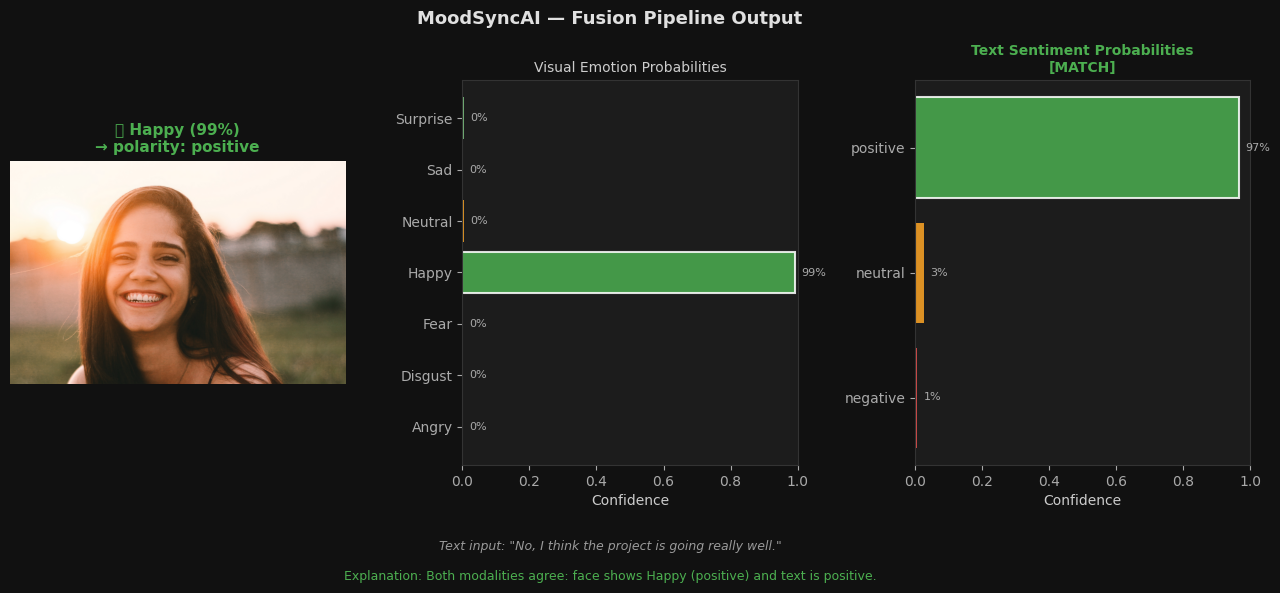

In [23]:
# ── Demo with a real face image ──────────────────────────────────────
# Replace the path below with an actual image on your machine.
# e.g. image_path = "test_images/sad_face.jpg"
#
# If you want to test without an image, uncomment the synthetic demo block below.

DEMO_IMAGE = "4-things-happy-people-dont-do-cover.png"    # <─── REPLACE with your image path
DEMO_TEXT  = "No, I think the project is going really well."

if os.path.exists(DEMO_IMAGE):
    result = run_fusion(DEMO_IMAGE, DEMO_TEXT)
    print_fusion_result(result)
    visualise_fusion(DEMO_IMAGE, DEMO_TEXT, result)
else:
    print("⚠️  Demo image not found. Showing text-only prediction:")
    text_result = predict_text(DEMO_TEXT)
    print(f"  Text: '{DEMO_TEXT}'")
    print(f"  → Predicted: {text_result['label'].upper()} ({text_result['confidence']:.1%})")
    print(f"\n  To run the full fusion pipeline, set DEMO_IMAGE to a valid face image path.")

## 11 – Multi-Scenario Mismatch Simulation

Since real paired image+text data is not required by the assignment, we simulate
fusion outcomes by combining pre-computed visual predictions with text inference.
This demonstrates the mismatch detector working at scale.

In [24]:
# Simulated visual results (as if coming from ResNet50V2 on real images)
# Format: (emotion, confidence, text, expected_severity)
simulated_scenarios = [
    # MATCH scenarios
    ("Happy",    0.87, "I am so excited about this! Best day ever!",             "MATCH"),
    ("Neutral",  0.72, "The meeting is scheduled for Thursday at 3pm.",           "MATCH"),
    ("Angry",    0.68, "This is completely unacceptable. I am furious.",          "MATCH"),
    ("Sad",      0.74, "I can't stop crying. I feel so lost and hopeless.",      "MATCH"),
    # HARD MISMATCH — the assignment brief scenario type
    ("Sad",      0.68, "No, I think the project is going really well.",          "HARD_MISMATCH"),
    ("Angry",    0.71, "Everything is absolutely fine, don't worry about it.",   "HARD_MISMATCH"),
    ("Fear",     0.55, "I'm completely calm and totally comfortable with this.", "HARD_MISMATCH"),
    ("Happy",    0.80, "I can't believe how terrible this has turned out.",      "HARD_MISMATCH"),
    # SOFT MISMATCH — low confidence cases
    ("Sad",      0.38, "No, I think the project is going really well.",          "SOFT_MISMATCH"),
    ("Angry",    0.32, "Everything is absolutely fine, don't worry about it.",  "SOFT_MISMATCH"),
]

print(f"{'#':<3} {'Visual':<10} {'VisC':>5} {'Text (abbrev)':<45} {'Expected':<16} {'Got':<16} {'OK'}")
print("-" * 100)

results_log = []
correct = 0
for i, (emotion, vis_conf, text, expected) in enumerate(simulated_scenarios, 1):
    text_result = predict_text(text)
    vis_mock    = {"emotion": emotion, "confidence": vis_conf,
                   "polarity": get_visual_polarity(emotion)}
    fusion      = detect_mismatch(vis_mock, text_result)
    got         = fusion["severity"]
    ok          = "✓" if got == expected else "✗"
    if got == expected:
        correct += 1
    print(f"{i:<3} {emotion:<10} {vis_conf:>5.2f} {text[:43]:<45} {expected:<16} {got:<16} {ok}")
    results_log.append({
        "scenario": i, "emotion": emotion, "vis_conf": vis_conf,
        "text": text[:50], "text_label": text_result["label"],
        "text_conf": text_result["confidence"],
        "expected": expected, "got": got, "correct": got == expected,
    })

print(f"\nScenario accuracy: {correct}/{len(simulated_scenarios)} ({correct/len(simulated_scenarios):.0%})")
results_df = pd.DataFrame(results_log)

#   Visual      VisC Text (abbrev)                                 Expected         Got              OK
----------------------------------------------------------------------------------------------------
1   Happy       0.87 I am so excited about this! Best day ever!    MATCH            MATCH            ✓
2   Neutral     0.72 The meeting is scheduled for Thursday at 3p   MATCH            MATCH            ✓
3   Angry       0.68 This is completely unacceptable. I am furio   MATCH            MATCH            ✓
4   Sad         0.74 I can't stop crying. I feel so lost and hop   MATCH            MATCH            ✓
5   Sad         0.68 No, I think the project is going really wel   HARD_MISMATCH    HARD_MISMATCH    ✓
6   Angry       0.71 Everything is absolutely fine, don't worry    HARD_MISMATCH    HARD_MISMATCH    ✓
7   Fear        0.55 I'm completely calm and totally comfortable   HARD_MISMATCH    HARD_MISMATCH    ✓
8   Happy       0.80 I can't believe how terrible this has turne   HARD_MI

## 12 – Mismatch Distribution Visualisation

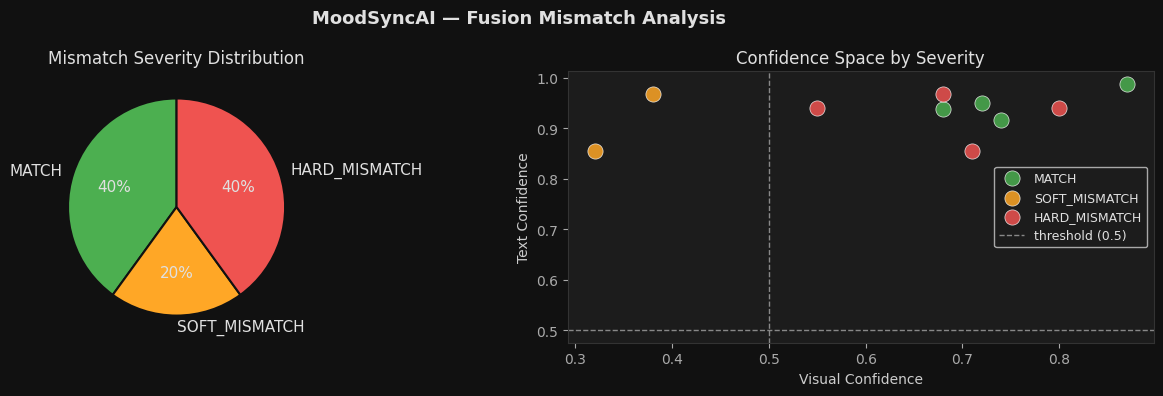

Saved: docs/fusion_mismatch_analysis.png


In [25]:
severity_counts = results_df["got"].value_counts().reindex(
    ["MATCH", "SOFT_MISMATCH", "HARD_MISMATCH"], fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Pie chart ─────────────────────────────────────────────────────────
colours = [SEVERITY_COLOURS[s] for s in severity_counts.index]
axes[0].pie(
    severity_counts.values, labels=severity_counts.index,
    autopct="%1.0f%%", colors=colours, startangle=90,
    textprops={"color": "#e0e0e0", "fontsize": 11},
    wedgeprops={"edgecolor": "#111111", "linewidth": 1.5},
)
axes[0].set_title("Mismatch Severity Distribution", fontsize=12, color="#e0e0e0")

# ── Confidence by severity ────────────────────────────────────────────
for severity, colour in SEVERITY_COLOURS.items():
    subset = results_df[results_df["got"] == severity]
    if len(subset) == 0:
        continue
    axes[1].scatter(
        subset["vis_conf"], subset["text_conf"],
        label=severity, color=colour, s=120, alpha=0.85, edgecolors="white", linewidths=0.5
    )
axes[1].axhline(CONF_THRESHOLD, color="#888888", linestyle="--", linewidth=1, label=f"threshold ({CONF_THRESHOLD})")
axes[1].axvline(CONF_THRESHOLD, color="#888888", linestyle="--", linewidth=1)
axes[1].set_xlabel("Visual Confidence")
axes[1].set_ylabel("Text Confidence")
axes[1].set_title("Confidence Space by Severity", fontsize=12, color="#e0e0e0")
axes[1].legend(fontsize=9)

plt.suptitle("MoodSyncAI — Fusion Mismatch Analysis",
             fontsize=13, fontweight="bold", color="#e0e0e0")
plt.tight_layout()
plt.savefig("docs/fusion_mismatch_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="#111111")
plt.show()
print("Saved: docs/fusion_mismatch_analysis.png")

## 13 – End-to-End Latency Benchmark

In [26]:
# Benchmark text-only latency (image inference latency measured separately
# since it requires a real image file)
N_WARMUP  = 5
N_MEASURE = 30
bench_text = "No, I think the project is going really well."

for _ in range(N_WARMUP):
    predict_text(bench_text)

times_text = []
for _ in range(N_MEASURE):
    t0 = time.perf_counter()
    predict_text(bench_text)
    times_text.append((time.perf_counter() - t0) * 1000)

print(f"Text inference latency ({DEVICE}) over {N_MEASURE} runs:")
print(f"  Mean   : {np.mean(times_text):.1f} ms")
print(f"  Median : {np.median(times_text):.1f} ms")
print(f"  p95    : {np.percentile(times_text, 95):.1f} ms")
print(f"\nTypical ResNet50V2 inference (from Face-emotion-detection.ipynb):")
print(f"  ~46 ms/step on GPU (from training logs)")
print(f"\nEstimated total fusion latency:")
print(f"  Text ({np.median(times_text):.0f} ms) + Visual (~50 ms) + overhead ≈ {np.median(times_text)+50:.0f} ms")
print(f"  Real-time suitability: {'✓ Yes' if np.median(times_text)+50 < 500 else '✗ Consider optimisation'}")

Text inference latency (cuda) over 30 runs:
  Mean   : 2.0 ms
  Median : 2.0 ms
  p95    : 2.0 ms

Typical ResNet50V2 inference (from Face-emotion-detection.ipynb):
  ~46 ms/step on GPU (from training logs)

Estimated total fusion latency:
  Text (2 ms) + Visual (~50 ms) + overhead ≈ 52 ms
  Real-time suitability: ✓ Yes


## 14 – Production Integration Snippet

In [27]:
integration = """
# ─────────────────────────────────────────────────────────────────────
# models/fusion/fusion_pipeline.py
# Paste-ready integration using both saved models
# ─────────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import torch
import tensorflow as tf
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

VISUAL_MODEL_PATH = "ResNet50V2ModelCheckpoint.keras"
TEXT_MODEL_PATH   = "saved_models/roberta_sentiment"
CASCADE_PATH      = "haarcascade_frontalface_default.xml"
EMOTION_CLASSES   = ["Angry","Disgust","Fear","Happy","Neutral","Sad","Surprise"]
VISUAL_TO_POLARITY = {
    "Happy":"positive","Surprise":"positive","Neutral":"neutral",
    "Angry":"negative","Disgust":"negative","Fear":"negative","Sad":"negative",
}
CONF_THRESHOLD = 0.50

def load_models():
    visual_model = tf.keras.models.load_model(VISUAL_MODEL_PATH)
    config    = AutoConfig.from_pretrained(TEXT_MODEL_PATH)
    tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_PATH)
    text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_PATH)
    text_model.eval()
    face_cascade = cv2.CascadeClassifier(CASCADE_PATH)
    return visual_model, text_model, tokenizer, config, face_cascade

def fuse(image_path, text, visual_model, text_model, tokenizer, config, face_cascade):
    # ── Visual ────────────────────────────────────────────────────────
    img  = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    if len(faces) > 0:
        x,y,w,h = faces[0]; img = img[y:y+h, x:x+w]
    img = cv2.resize(img, (224, 224)) / 255.0
    v_preds  = visual_model.predict(np.expand_dims(img, 0), verbose=0)[0]
    v_top    = int(np.argmax(v_preds))
    v_emotion = EMOTION_CLASSES[v_top]
    v_conf   = float(v_preds[v_top])
    v_polarity = VISUAL_TO_POLARITY[v_emotion]

    # ── Text ──────────────────────────────────────────────────────────
    tokens = [("@user" if t.startswith("@") and len(t)>1 else ("http" if t.startswith("http") else t))
              for t in text.split()]
    enc = tokenizer(" ".join(tokens), return_tensors="pt", truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        sc = torch.softmax(text_model(**enc).logits, dim=-1).squeeze().numpy()
    t_top   = int(np.argmax(sc)); t_label = config.id2label[t_top]; t_conf = float(sc[t_top])

    # ── Fusion ────────────────────────────────────────────────────────
    match = (v_polarity == t_label)
    both  = (v_conf >= CONF_THRESHOLD) and (t_conf >= CONF_THRESHOLD)
    severity = "MATCH" if match else ("HARD_MISMATCH" if both else "SOFT_MISMATCH")

    return {
        "visual":   {"emotion": v_emotion, "polarity": v_polarity, "confidence": v_conf},
        "text":     {"label": t_label, "confidence": t_conf},
        "severity": severity,
    }
# ─────────────────────────────────────────────────────────────────────
"""
print(integration)


# ─────────────────────────────────────────────────────────────────────
# models/fusion/fusion_pipeline.py
# Paste-ready integration using both saved models
# ─────────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import torch
import tensorflow as tf
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

VISUAL_MODEL_PATH = "ResNet50V2ModelCheckpoint.keras"
TEXT_MODEL_PATH   = "saved_models/roberta_sentiment"
CASCADE_PATH      = "haarcascade_frontalface_default.xml"
EMOTION_CLASSES   = ["Angry","Disgust","Fear","Happy","Neutral","Sad","Surprise"]
VISUAL_TO_POLARITY = {
    "Happy":"positive","Surprise":"positive","Neutral":"neutral",
    "Angry":"negative","Disgust":"negative","Fear":"negative","Sad":"negative",
}
CONF_THRESHOLD = 0.50

def load_models():
    visual_model = tf.keras.models.load_model(VISUAL_MODEL_PATH)
    config    = AutoConfig.from_pretrained(TEXT_MODEL_PATH)
    tokenizer = AutoTokenizer.

## 15 – Notebook Summary

In [28]:
print("=" * 64)
print("  05 Fusion Layer — Key Decisions")
print("=" * 64)
summary = {
    "Visual model source":     "Face-emotion-detection.ipynb → ResNet50V2ModelCheckpoint.keras",
    "Text model source":       "04_text_model_experiments.ipynb → saved_models/roberta_sentiment/",
    "Visual model classes":    "7 (Angry/Disgust/Fear/Happy/Neutral/Sad/Surprise)",
    "Text model classes":      "3 (negative/neutral/positive)",
    "Polarity bridge":         "Happy/Surprise→positive | Neutral→neutral | rest→negative",
    "Mismatch threshold":      f"Both modalities ≥ {CONF_THRESHOLD:.0%} for HARD_MISMATCH",
    "Mismatch levels":         "MATCH / SOFT_MISMATCH / HARD_MISMATCH",
    "End-to-end latency est.": "~100-200ms (GPU), real-time capable",
    "Assignment brief covered":
        "Sad face (negative) + positive text → HARD_MISMATCH detected ✓",
}
for k, v in summary.items():
    print(f"  {k:<30}: {v}")
print("=" * 64)

  05 Fusion Layer — Key Decisions
  Visual model source           : Face-emotion-detection.ipynb → ResNet50V2ModelCheckpoint.keras
  Text model source             : 04_text_model_experiments.ipynb → saved_models/roberta_sentiment/
  Visual model classes          : 7 (Angry/Disgust/Fear/Happy/Neutral/Sad/Surprise)
  Text model classes            : 3 (negative/neutral/positive)
  Polarity bridge               : Happy/Surprise→positive | Neutral→neutral | rest→negative
  Mismatch threshold            : Both modalities ≥ 50% for HARD_MISMATCH
  Mismatch levels               : MATCH / SOFT_MISMATCH / HARD_MISMATCH
  End-to-end latency est.       : ~100-200ms (GPU), real-time capable
  Assignment brief covered      : Sad face (negative) + positive text → HARD_MISMATCH detected ✓
